## Introduction to Multimodel AI
- from one type of data into multiple modalities seemlessly (various data froms like text, audio, image etc)

### Multimodal AI
- single modal AI
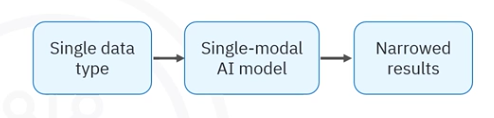

- Multimodal AI
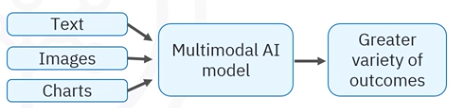
- can process and undertand multiple types of data simultaniously
- closely mimics how humens interacts with the world

### Evalution of AI
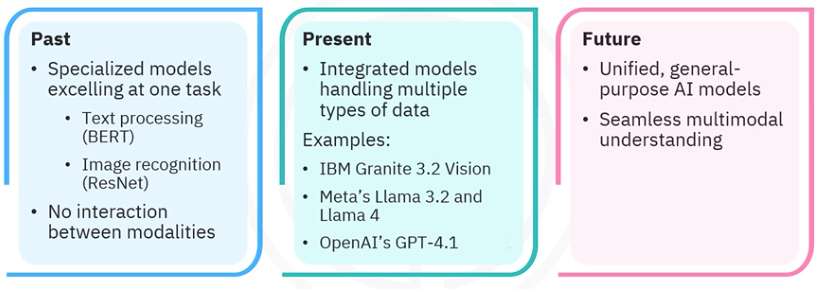

### Key functionalities of Mulitmodal AI
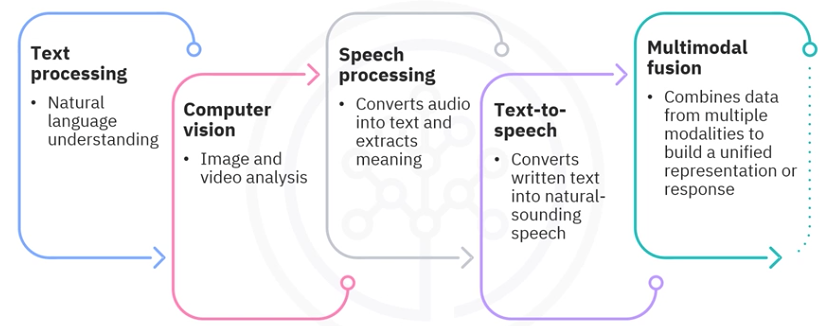

### How Multimodal AI works
- Each input is processed by seperate encoders
- System extract key-features from each modalities
- Differnet types of data is properly synchronized
- Combines information from all modalities to synchronize infromation
- System genreate information using information from all the modalities

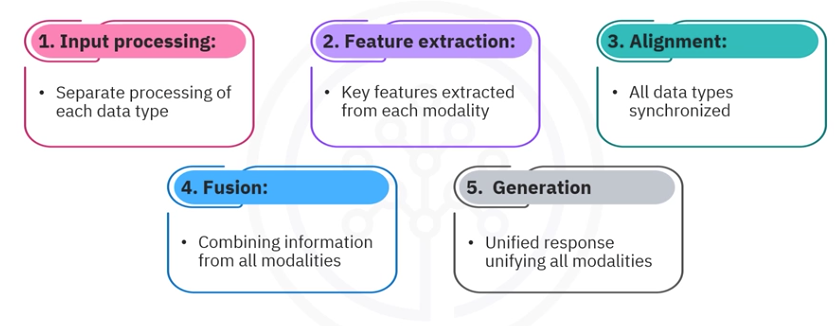

### Applications for Multimodal AI
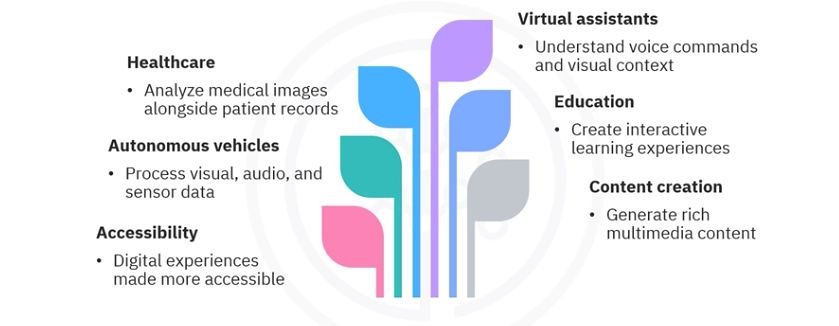

### Industry leaders in Multimodal AI
- IBM Granite 3.2 Vision
    - document understanding
- OpenAI
    - GPT 4.o
    - CLIP
    - DALL-E
- Meta
    - Llama 4
    - Llama 3.2 Vision
- Google
    - Gemini
    - Gemma
- Antropic
    - Claude 3.7 Sonnet

### Challenges in multimodal AI
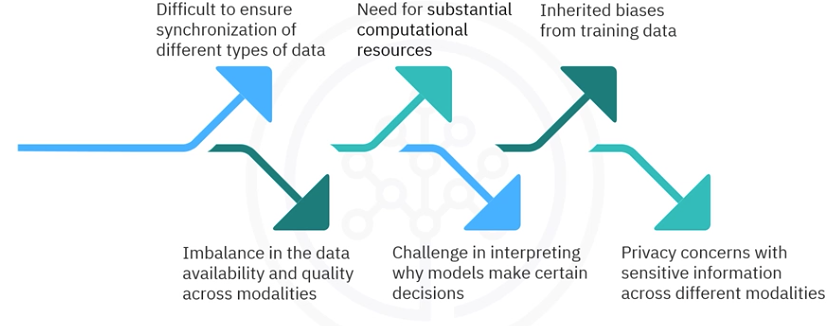

### Future
- Unified Models
    - a single model capable of handling all modalites
- Edge computing
    - Running models directly on devices to improve privacy, speed and accessibility
- Self-supervised learning techniques
    - Reduced relience on large labeled dataset by learning from unlabeled data
- Personaliztion
    - Adapt to individual user preferences
- Ethical AI
    - Emphasiyes on fairness, transparency, and responible use in multimodal system




## Text-to-Speech Technologies
- Text to Speech (TTS)
- Evolution of TTS
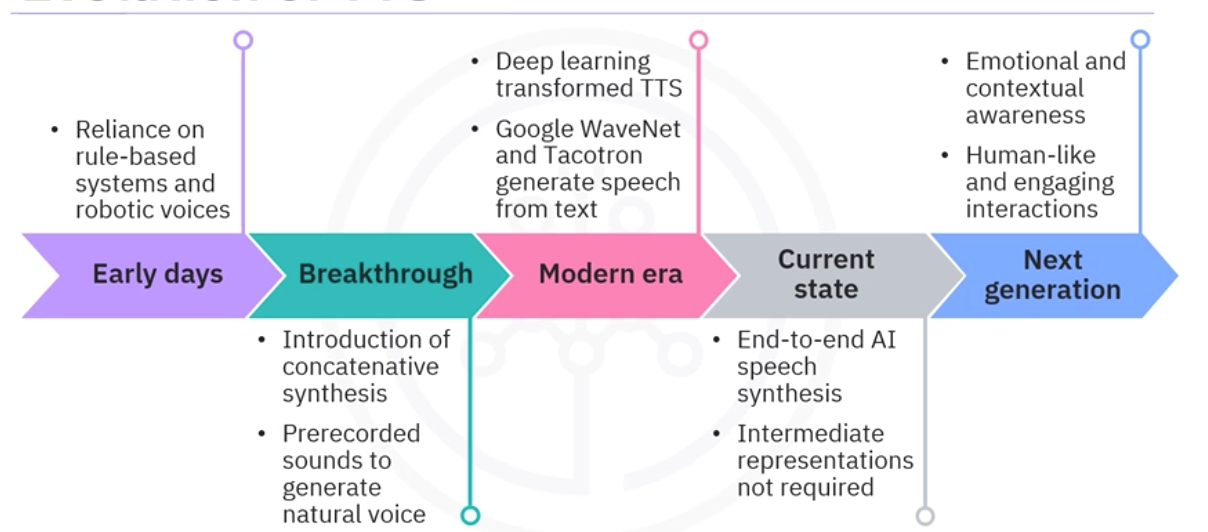

- Modern TTS architecture
    - Text analysis and normalization
        - Abbrivation expansion
        - Bymber to word conversion
        - Grapheme-to-phoneme conversion (written text to sound)
    - Lingustic feature extraction
        - Syntax, semantics, and Prosody (rhythm or intonation of speech)
    - Acostic model processing
        - Pitch, duration, and energy prediction
        - Natural speech production 
        - Intermediate repsrenations generation
    - Neural voice generaton
    - Audio waveform synthesis
        - Human like speech production

- End-to-end Text to Speech systems
- VITS
    - Directly mpas text to Audio
    - 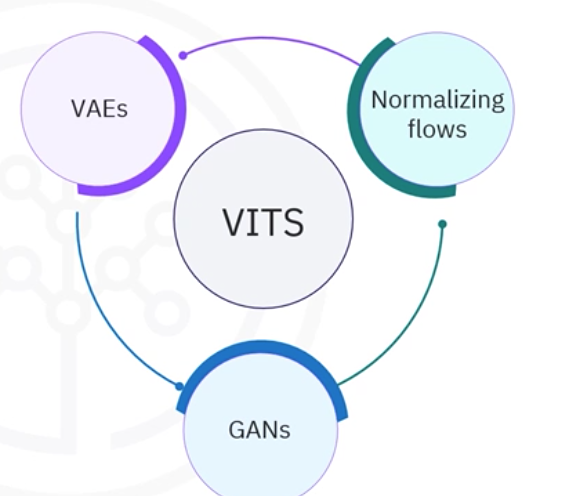
    - generate natural high quality speech


In [6]:
! pip install torchaudio | tail -n 1
! pip install transformers | tail -n 1
! pip install torchcodec | tail -n 1

In [7]:
import torch
import torchaudio
from transformers import VitsModel, AutoTokenizer

def generate_speech(text):
    # Load pre-trained model and tokenizer
    model = VitsModel.from_pretrained("facebook/mms-tts-eng")
    tokenizer = AutoTokenizer.from_pretrained("facebook/mms-tts-eng")   

    # Tokenize input text
    inputs = tokenizer(text, return_tensors="pt")

    # Generate speech
    with torch.no_grad():
        output = model(**inputs).waveform # No Speaker_id

    return output

if __name__ == "__main__":
    text = "Hello, this is a test of the VITS text-to-speech model."
    speech = generate_speech(text)

    # Save the generated speech to a file
    torchaudio.save("output.wav", speech.cpu(), sample_rate=22050)

Loading weights: 100%|██████████| 762/762 [00:00<00:00, 12587.97it/s]


### Challenges to TTS
- Natural prosody
- Emotional content requires complex processing
- Multi-speaker syntesis is challenging
- Real-time processing requeres optimization (latency reduction)
- Cross-lingual support is also challenging

### Getting started with TTS
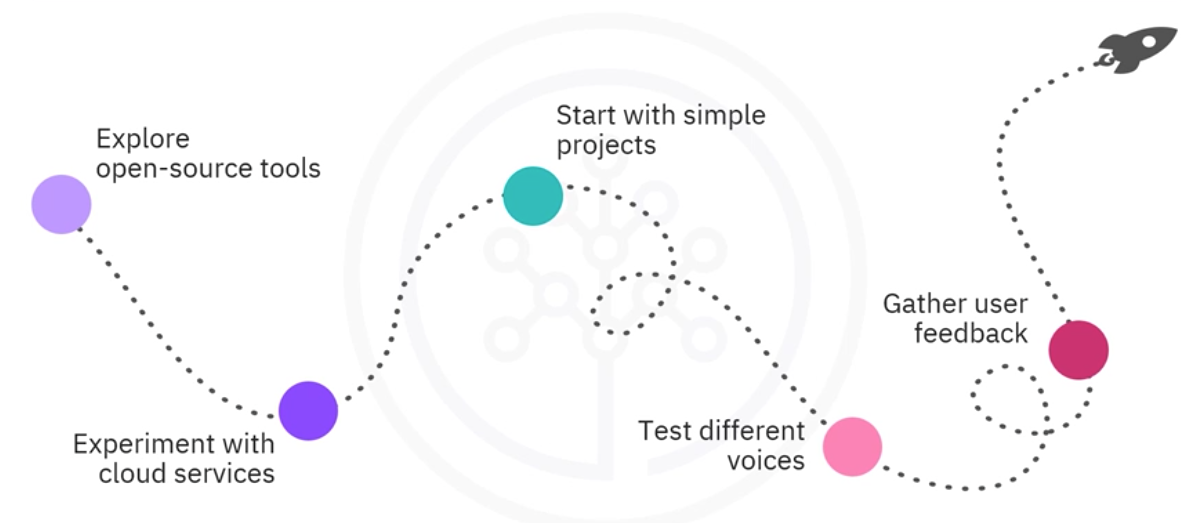

## Speech-to-Text Technologies
- Speech-to-Text (STT)
- Transforming spoken language into written text
- combines
    - Audio processing
    - Natural langauge understanding
- the Technology is also called **Automatic speech recognition (ASR)**

### Evalution of STT
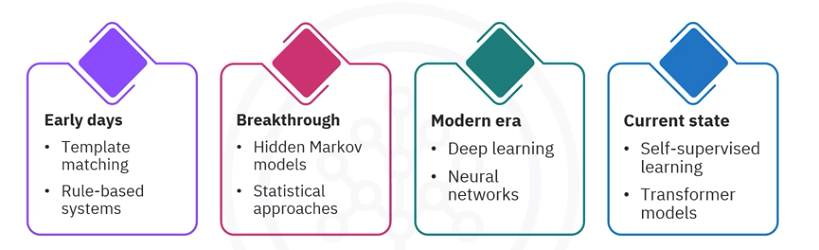

### How does STT works
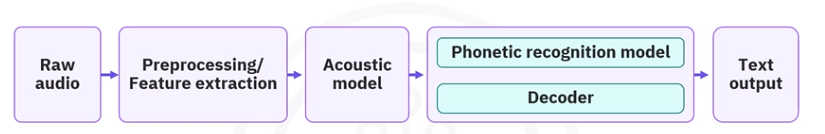

- Raw audio
    - input
    - noise reduction
- Preprocessing / Feature Extraction
    - more informative representation
    - Spectrogram / MFCCs
    - a fromat more suitable for machine learning models
- Acoustic Model
    - convert features into sound patterns
    - 4 milli second audio (Phonems)
- Phonetic recognition model
    - maps phonems into subwrods
- Decoder
    - makes words from subwords
    - a language model is used to improve accuracy (gives context to the word generation)
- Text output
    - system output the text
    - with punctuation and format for readability



In [13]:
import torch
from transformers import AutoModelForSpeechSeq2Seq, AutoProcessor, pipeline

def transcribe_audio(audio_path):
    device = "cuda:0" if torch.cuda.is_available() else "cpu"
    torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

    # 1. Load the correct model type (ASR)
    model_id = "openai/whisper-tiny" # Use "base" or "small" for better accuracy

    model = AutoModelForSpeechSeq2Seq.from_pretrained(
        model_id, torch_dtype=torch_dtype, low_cpu_mem_usage=True, use_safetensors=True
    ).to(device)

    processor = AutoProcessor.from_pretrained(model_id)

    # 2. Use a pipeline for easier handling of audio preprocessing
    pipe = pipeline(
        "automatic-speech-recognition",
        model=model,
        tokenizer=processor.tokenizer,
        feature_extractor=processor.feature_extractor,
        dtype=torch_dtype,
        device=device,
    )

    # 3. Transcribe
    result = pipe(audio_path)
    return result["text"]

if __name__ == "__main__":
    # Ensure 'output.wav' exists in your directory
    audio_path = "output.wav" 
    try:
        transcription = transcribe_audio(audio_path)
        print("Transcription:", transcription)
    except Exception as e:
        print(f"Error: {e}")

Loading weights: 100%|██████████| 167/167 [00:00<00:00, 3983.69it/s]


Transcription:  Hello, this is a test of the Vitz, text to speech model.


### Application
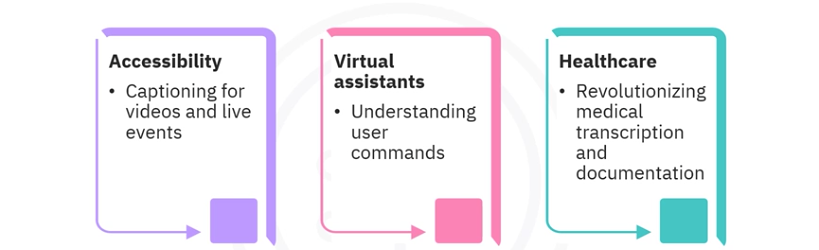
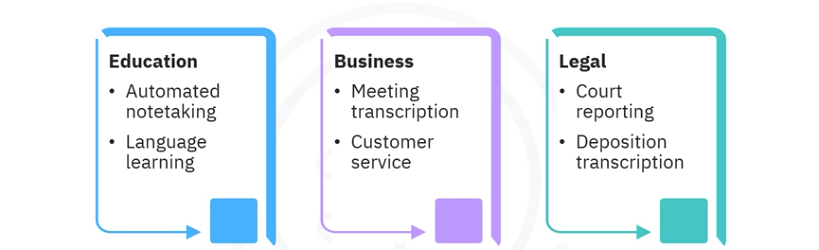

### Challenges
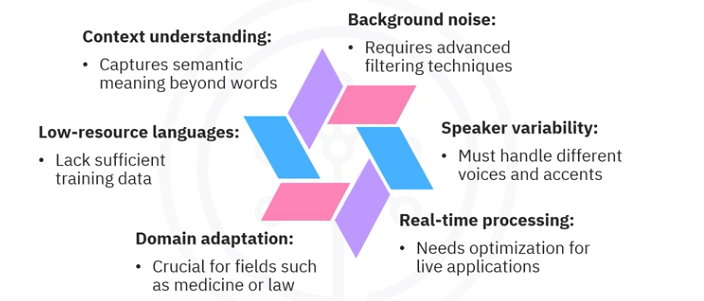

### Future of STT
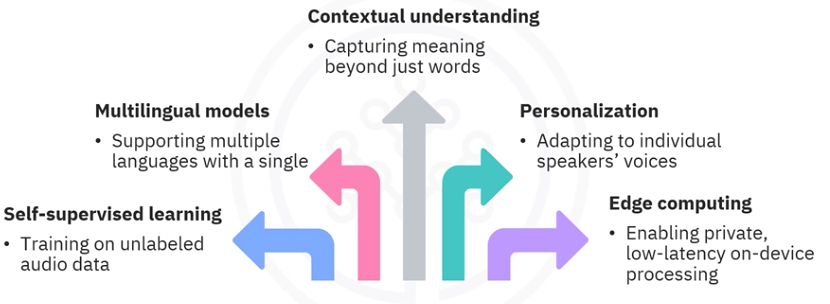

### Getting started with STT
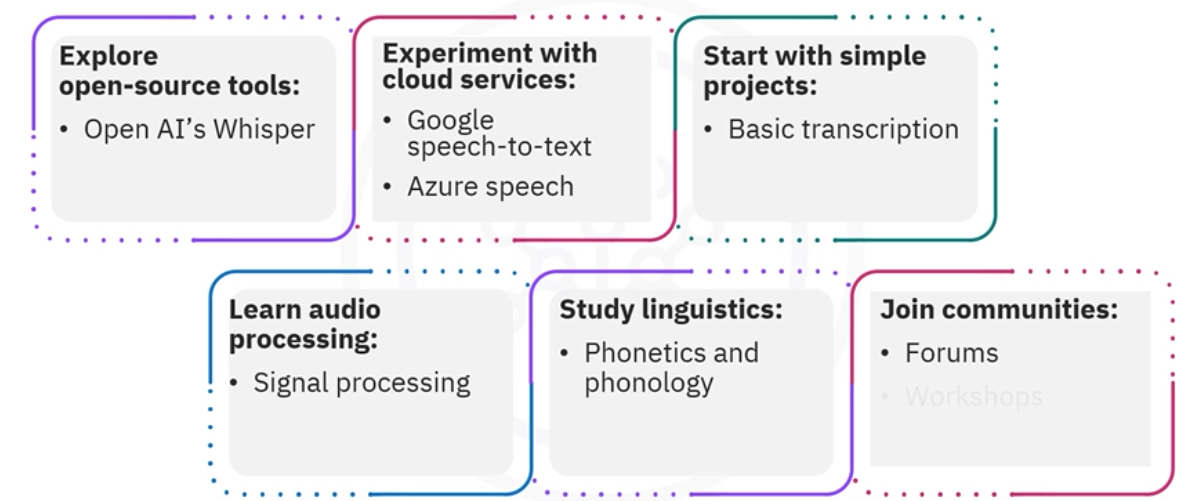